In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import pandas as pd
import decoupler as dc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
project_dir = os.path.expanduser("~/BreastCancerG0arrest/")
working_dir = os.path.join(project_dir, "00_revisions/")
figure_dir = os.path.join(working_dir, "figures/")
data_dir = os.path.join(working_dir, "data/")

In [5]:
adata = sc.read_h5ad(data_dir + "adata_full_harmony_integration.h5ad")

In [6]:
malignant_cells = ["G0-arrested", "Fast-cycling", "Slow-cycling"]
adata = adata[adata.obs["cycling_state_oren"].isin(malignant_cells)].copy()

In [7]:
adata.X = adata.layers["counts"].copy()

In [8]:
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

In [20]:
atf4_reactome = pd.read_csv("REACTOME_ATF4_ACTIVATES_GENES_IN_RESPONSE_TO_ENDOPLASMIC_RETICULUM_STRESS.v2025.1.Hs.tsv", sep="\t", header=None, skiprows=17)
atf4_reactome = (atf4_reactome.loc[atf4_reactome[0] == "GENE_SYMBOLS", 1].iloc[0].split(","))
atf4_reactome = pd.DataFrame({"source": "ATF4 activates genes in response to ER stress", "target": atf4_reactome})

ifnab_reactome = pd.read_csv("REACTOME_INTERFERON_ALPHA_BETA_SIGNALING.v2025.1.Hs.tsv", sep="\t", header=None, skiprows=17)
ifnab_reactome = (ifnab_reactome.loc[ifnab_reactome[0] == "GENE_SYMBOLS", 1].iloc[0].split(","))
ifnab_reactome = pd.DataFrame({"source": "IFN⍺/β signalling", "target": ifnab_reactome})

ifng_reactome = pd.read_csv("REACTOME_INTERFERON_GAMMA_SIGNALING.v2025.1.Hs.tsv", sep="\t", header=None, skiprows=17)
ifng_reactome = (ifng_reactome.loc[ifng_reactome[0] == "GENE_SYMBOLS", 1].iloc[0].split(","))
ifng_reactome = pd.DataFrame({"source": "IFNγ signalling", "target": ifng_reactome})

tgfb_reactome = pd.read_csv("REACTOME_SIGNALING_BY_TGF_BETA_RECEPTOR_COMPLEX.v2025.1.Hs.tsv", sep="\t", header=None, skiprows=17)
tgfb_reactome = (tgfb_reactome.loc[tgfb_reactome[0] == "GENE_SYMBOLS", 1].iloc[0].split(","))
tgfb_reactome = pd.DataFrame({"source": "Signalling by TGF-β receptor complex", "target": tgfb_reactome})

emt_hallmark = pd.read_csv("HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION.v2026.1.Hs.tsv", sep="\t", header=None, skiprows=17)
emt_reactome = (emt_hallmark.loc[emt_hallmark[0] == "GENE_SYMBOLS", 1].iloc[0].split(","))
emt_reactome = pd.DataFrame({"source": "EMT", "target": emt_reactome})

senescence_reactome = pd.read_csv("REACTOME_CELLULAR_SENESCENCE.v2026.1.Hs.tsv", sep="\t", header=None, skiprows=17)
senescence_reactome = (senescence_reactome.loc[senescence_reactome[0] == "GENE_SYMBOLS", 1].iloc[0].split(","))
senescence_reactome = pd.DataFrame({"source": "Cellular senescence", "target": senescence_reactome})

# Combine pathways
pathways_reactome = pd.concat([atf4_reactome, ifnab_reactome, ifng_reactome, tgfb_reactome, emt_reactome, senescence_reactome], ignore_index=True)
# drop duplicates
pathways_reactome = pathways_reactome.drop_duplicates()

In [21]:
dc.mt.aucell(adata, net=pathways_reactome)

In [22]:
score = dc.pp.get_obsm(adata, key="score_aucell")

In [12]:
from scipy.stats import mannwhitneyu
import itertools
import math
import numpy as np
import pandas as pd


def plot_scores(
    score,
    group_column: str,
    signatures,
    obsm_key: str = "score_aucell",
    order=None,
    colours=None,
    figsize=(3, 3),
    xlabel=None,
    ylabel=None,
    title=None,
    log_y=False,
    save=None,
    return_stats=False,
):
    """
    Violin + box plots of signature scores stored in score.obsm[obsm_key],
    grouped by a categorical column in score.obs.
    Adds significance stars (only for p < 0.05) based on pairwise Mann–Whitney U tests.
    Supports multiple signatures in subplots.
    """

    if isinstance(signatures, str):
        signatures = [signatures]

    if obsm_key not in score.obsm:
        raise ValueError(f"{obsm_key} not found in score.obsm")

    score_mat = score.obsm[obsm_key]

    for s in signatures:
        if s not in score_mat.columns:
            raise ValueError(f"Signature '{s}' not found in score.obsm['{obsm_key}']")

    groups = score.obs[group_column].dropna().unique()
    if order is None:
        order = sorted(groups)

    if colours is not None:
        if len(colours) < len(order):
            raise ValueError("Number of colours must match number of groups")
        palette = dict(zip(order, colours))
    else:
        palette = dict(zip(order, sns.color_palette("Set2", len(order))))

    n_sig = len(signatures)
    ncols = min(3, n_sig)
    nrows = math.ceil(n_sig / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize[0] * ncols, figsize[1] * nrows),
        squeeze=False,
    )

    stats_all = []

    for idx, sig in enumerate(signatures):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        obs = score.obs[[group_column]].copy()
        obs["score"] = score_mat.loc[obs.index, sig]
        obs = obs.dropna(subset=["score"])

        sns.violinplot(
            data=obs,
            x=group_column,
            y="score",
            order=order,
            palette=palette,
            inner="box",
            ax=ax,
            cut=0,
        )

        ax.set_xlabel(xlabel or group_column, fontsize=10)
        ax.set_ylabel(ylabel or "Score", fontsize=10)
        ax.set_title(sig, fontsize=11)

        if log_y:
            ax.set_yscale("log")

        sns.despine(ax=ax)

        pairs = list(itertools.combinations(order, 2))
        ymax = obs["score"].max()
        y_offsets = np.linspace(0.05 * ymax, 0.2 * ymax, len(pairs))

        for i, (g1, g2) in enumerate(pairs):
            d1 = obs.loc[obs[group_column] == g1, "score"]
            d2 = obs.loc[obs[group_column] == g2, "score"]

            stat, p = mannwhitneyu(d1, d2, alternative="two-sided")
            stats_all.append(
                {
                    "signature": sig,
                    "group1": g1,
                    "group2": g2,
                    "U": stat,
                    "pvalue": p,
                }
            )

            if p < 0.05:
                if p < 0.001:
                    stars = "***"
                elif p < 0.01:
                    stars = "**"
                else:
                    stars = "*"

                x1, x2 = order.index(g1), order.index(g2)
                y = ymax + y_offsets[i]

                ax.plot(
                    [x1, x1, x2, x2],
                    [y - 0.02 * ymax, y, y, y - 0.02 * ymax],
                    lw=1,
                    c="black",
                )
                ax.text(
                    (x1 + x2) / 2,
                    y + 0.02 * ymax,
                    stars,
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        ax.tick_params(axis="both", labelsize=9)
        ax.grid(False)

    for j in range(idx + 1, nrows * ncols):
        fig.delaxes(axes.flatten()[j])

    if title:
        fig.suptitle(title, fontsize=13)

    plt.tight_layout()
    if title:
        plt.subplots_adjust(top=0.9)

    if save:
        plt.savefig(save, bbox_inches="tight")

    plt.show()

    if return_stats:
        return pd.DataFrame(stats_all)

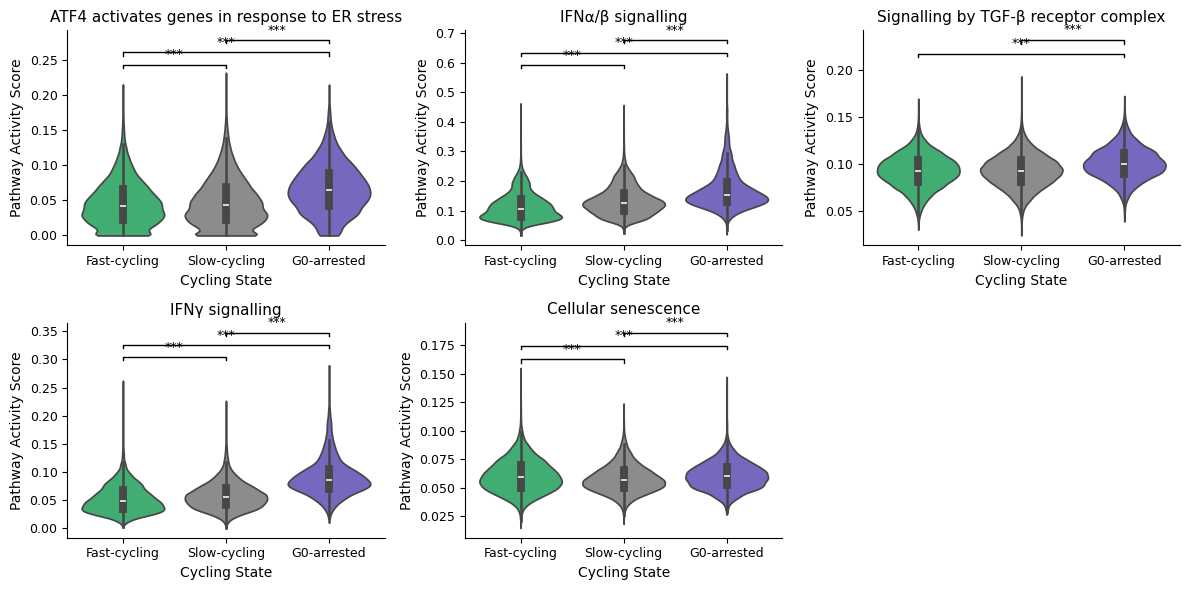

In [ ]:
plot_scores(
    adata,
    group_column="cycling_state_oren",
    signatures=[
        "ATF4 activates genes in response to ER stress",
        "IFN⍺/β signalling",
        "Signalling by TGF-β receptor complex",
        "IFNγ signalling",
        "EMT",
        "Cellular senescence",
    ],
    obsm_key="score_aucell",
    order=["Fast-cycling", "Slow-cycling", "G0-arrested"],
    colours=["#2FBF71", "#8C8C8C", "#6A5ACD"],
    figsize=(4, 3),
    xlabel="Cycling State",
    ylabel="Pathway Activity Score",
    log_y=False,
    save=figure_dir + "reactome_pathway_activity_scores_by_cycling_state.pdf",
)

In [14]:
# Translation Initiation Factors (eIF) - 54 genes
eIF_signature = {
    # eIF1 family
    "EIF1": "Eukaryotic translation initiation factor 1",
    "EIF1AX": "Eukaryotic translation initiation factor 1A X-linked",
    "EIF1AY": "Eukaryotic translation initiation factor 1A Y-linked",
    "EIF1B": "Eukaryotic translation initiation factor 1B",
    # eIF2 family (including kinases)
    "EIF2A": "Eukaryotic translation initiation factor 2A",
    "EIF2AK1": "eIF2 alpha kinase 1 (HRI)",
    "EIF2AK2": "eIF2 alpha kinase 2 (PKR)",
    "EIF2AK3": "eIF2 alpha kinase 3 (PERK)",
    "EIF2AK4": "eIF2 alpha kinase 4 (GCN2)",
    "EIF2B1": "eIF2B subunit alpha",
    "EIF2B2": "eIF2B subunit beta",
    "EIF2B3": "eIF2B subunit gamma",
    "EIF2B4": "eIF2B subunit delta",
    "EIF2B5": "eIF2B subunit epsilon",
    "EIF2D": "Eukaryotic translation initiation factor 2D",
    "EIF2S1": "eIF2 subunit alpha",
    "EIF2S2": "eIF2 subunit beta",
    "EIF2S3": "eIF2 subunit gamma",
    # eIF3 family
    "EIF3A": "eIF3 subunit A",
    "EIF3B": "eIF3 subunit B",
    "EIF3C": "eIF3 subunit C",
    "EIF3CL": "eIF3 subunit C-like",
    "EIF3D": "eIF3 subunit D",
    "EIF3E": "eIF3 subunit E",
    "EIF3F": "eIF3 subunit F",
    "EIF3G": "eIF3 subunit G",
    "EIF3H": "eIF3 subunit H",
    "EIF3I": "eIF3 subunit I",
    "EIF3J": "eIF3 subunit J",
    "EIF3K": "eIF3 subunit K",
    "EIF3L": "eIF3 subunit L",
    "EIF3M": "eIF3 subunit M",
    # eIF4 family
    "EIF4A1": "eIF4A1 (RNA helicase)",
    "EIF4A2": "eIF4A2 (RNA helicase)",
    "EIF4A3": "eIF4A3 (RNA helicase)",
    "EIF4B": "eIF4B",
    "EIF4E": "eIF4E (cap-binding protein)",
    "EIF4E1B": "eIF4E family member 1B",
    "EIF4E2": "eIF4E family member 2",
    "EIF4E3": "eIF4E family member 3",
    "EIF4EBP1": "4E-BP1 (eIF4E binding protein 1)",
    "EIF4EBP2": "4E-BP2 (eIF4E binding protein 2)",
    "EIF4EBP3": "4E-BP3 (eIF4E binding protein 3)",
    "EIF4ENIF1": "eIF4E nuclear import factor 1",
    "EIF4G1": "eIF4G1 (scaffold protein)",
    "EIF4G2": "eIF4G2 (DAP5)",
    "EIF4G3": "eIF4G3",
    "EIF4H": "eIF4H",
    # eIF5 family
    "EIF5": "eIF5 (GTPase activating protein)",
    "EIF5A": "eIF5A (hypusine-containing)",
    "EIF5A2": "eIF5A2",
    "EIF5AL1": "eIF5A-like 1",
    "EIF5B": "eIF5B (ribosome-dependent GTPase)",
    # eIF6
    "EIF6": "eIF6 (anti-association factor)",
}

# Translation Elongation Factors (eEF) - 14 genes
eEF_signature = {
    # eEF1 family
    "EEF1A1": "eEF1A1 (GTP-binding, aminoacyl-tRNA delivery)",
    "EEF1A2": "eEF1A2 (tissue-specific isoform)",
    "EEF1B2": "eEF1B2 (guanine nucleotide exchange)",
    "EEF1D": "eEF1D (guanine nucleotide exchange)",
    "EEF1E1": "eEF1E1",
    "EEF1G": "eEF1G (guanine nucleotide exchange)",
    # eEF2 family
    "EEF2": "eEF2 (ribosomal translocation)",
    "EEF2K": "eEF2 kinase (regulatory)",
    "EEF2KMT": "eEF2 lysine methyltransferase",
    # Selenocysteine-specific
    "EEFSEC": "Selenocysteine-tRNA-specific elongation factor",
    # Mitochondrial elongation factors
    "TUFM": "Tu translation elongation factor, mitochondrial",
    "TSFM": "Ts translation elongation factor, mitochondrial",
    "GFM1": "G elongation factor mitochondrial 1",
    "GFM2": "G elongation factor mitochondrial 2",
}

# Simple gene lists for scoring
eIF_genes = list(eIF_signature.keys())
eEF_genes = list(eEF_signature.keys())

signatures_df = pd.DataFrame({
    "source": ["eIF"] * len(eIF_genes) + ["eEF"] * len(eEF_genes),
    "target": eIF_genes + eEF_genes
})

In [15]:
dc.mt.aucell(adata, net=signatures_df)

In [16]:
score = dc.pp.get_obsm(adata, key="score_aucell")

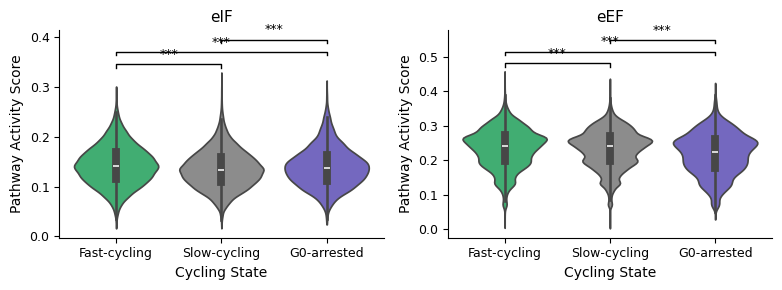

In [17]:
plot_scores(
    adata,
    group_column="cycling_state_oren",
    signatures=[
        "eIF",
        "eEF",
    ],
    obsm_key="score_aucell",
    order=["Fast-cycling", "Slow-cycling", "G0-arrested"],
    colours=["#2FBF71", "#8C8C8C", "#6A5ACD"],
    figsize=(4, 3),
    xlabel="Cycling State",
    ylabel="Pathway Activity Score",
    log_y=False,
    save=figure_dir + "eukaryotic_translation_scores_by_cycling_state.pdf",
)

In [18]:
# eIF2 kinases - ISR sensors (phosphorylate eIF2α to inhibit global translation)
eIF2_kinases = ["EIF2AK1", "EIF2AK2", "EIF2AK3", "EIF2AK4"]

# eIF4 complex - Core cap-dependent translation initiation machinery
eIF4_complex = ["EIF4A1", "EIF4A2", "EIF4B", "EIF4E", "EIF4G1", "EIF4G2", "EIF4H"]

# 4E-BPs - mTOR-regulated inhibitors of eIF4E (translation suppressors)
eIF4_BPs = ["EIF4EBP1", "EIF4EBP2", "EIF4EBP3"]

# eEF1 complex - Elongation machinery (aminoacyl-tRNA delivery)
eEF1_complex = ["EEF1A1", "EEF1A2", "EEF1B2", "EEF1D", "EEF1G"]

# eEF2 regulatory - Elongation control
eEF2_regulatory = ["EEF2", "EEF2K"]

# Check gene availability in adata
all_subgroups = {
    "eIF2 kinases (ISR)": eIF2_kinases,
    "eIF4 complex": eIF4_complex,
    "4E-BPs (mTOR targets)": eIF4_BPs,
    "eEF1 complex": eEF1_complex,
    "eEF2 regulatory": eEF2_regulatory,
}

print("Gene availability per subgroup:")
for name, genes in all_subgroups.items():
    present = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]
    print(f"\n{name}: {len(present)}/{len(genes)} genes present")
    if missing:
        print(f"  Missing: {missing}")


Gene availability per subgroup:

eIF2 kinases (ISR): 4/4 genes present

eIF4 complex: 7/7 genes present

4E-BPs (mTOR targets): 3/3 genes present

eEF1 complex: 5/5 genes present

eEF2 regulatory: 2/2 genes present


In [19]:
for name, genes in all_subgroups.items():
    present_genes = [g for g in genes if g in adata.var_names]
    if len(present_genes) >= 2:
        score_name = name.replace(" ", "_").replace("(", "").replace(")", "")
        sc.tl.score_genes(adata, gene_list=present_genes, score_name=score_name)
        print(f"Scored: {name} ({len(present_genes)} genes)")
    else:
        print(f"Skipped: {name} (only {len(present_genes)} gene(s) available)")

Scored: eIF2 kinases (ISR) (4 genes)
Scored: eIF4 complex (7 genes)
Scored: 4E-BPs (mTOR targets) (3 genes)
Scored: eEF1 complex (5 genes)
Scored: eEF2 regulatory (2 genes)


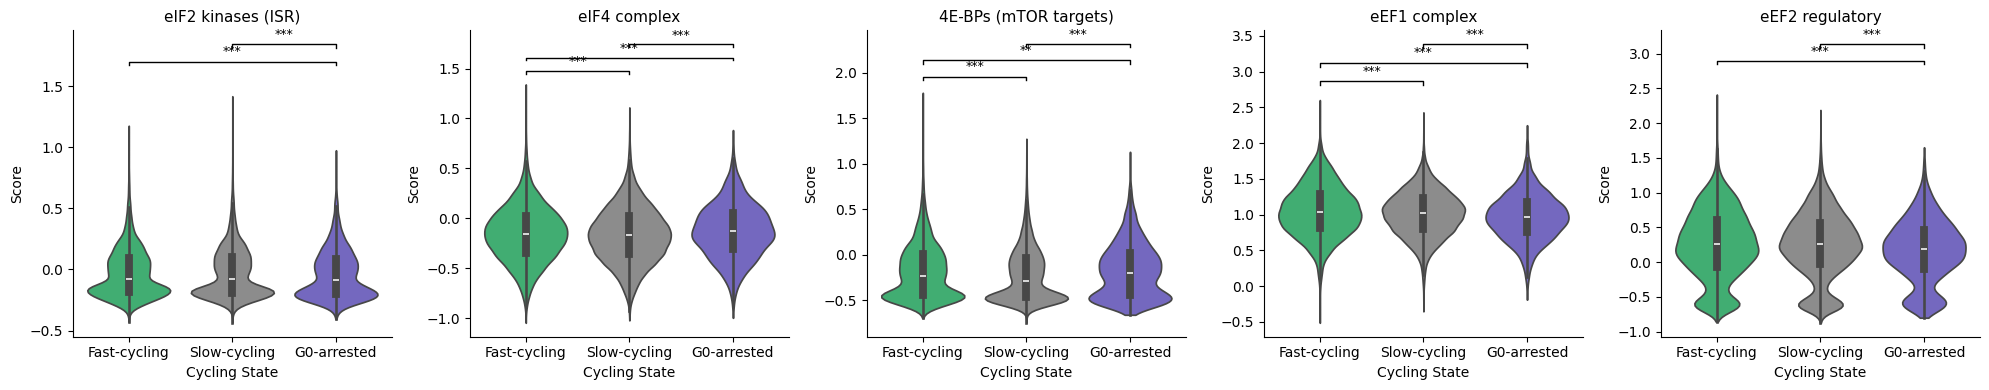

In [20]:
score_columns = [
    col
    for col in adata.obs.columns
    if any(
        key in col
        for key in [
            "eIF2_kinases",
            "eIF4_complex",
            "4E-BPs",
            "eEF1_complex",
            "eEF2_regulatory",
        ]
    )
]

fig, axes = plt.subplots(1, len(score_columns), figsize=(4 * len(score_columns), 4))
if len(score_columns) == 1:
    axes = [axes]

order = ["Fast-cycling", "Slow-cycling", "G0-arrested"]
colours = {
    "Fast-cycling": "#2FBF71",
    "Slow-cycling": "#8C8C8C",
    "G0-arrested": "#6A5ACD",
}

for ax, score_col in zip(axes, score_columns):
    sns.violinplot(
        data=adata.obs,
        x="cycling_state_oren",
        y=score_col,
        order=order,
        palette=colours,
        inner="box",
        ax=ax,
        cut=0,
    )

    # Add significance testing
    pairs = list(itertools.combinations(order, 2))
    ymax = adata.obs[score_col].max()
    y_offsets = np.linspace(0.1 * abs(ymax), 0.3 * abs(ymax), len(pairs))

    for i, (g1, g2) in enumerate(pairs):
        d1 = adata.obs.loc[adata.obs["cycling_state_oren"] == g1, score_col]
        d2 = adata.obs.loc[adata.obs["cycling_state_oren"] == g2, score_col]
        stat, p = mannwhitneyu(d1, d2, alternative="two-sided")

        if p < 0.05:
            stars = "***" if p < 0.001 else ("**" if p < 0.01 else "*")
            x1, x2 = order.index(g1), order.index(g2)
            y = ymax + y_offsets[i]
            ax.plot(
                [x1, x1, x2, x2],
                [y - 0.02 * abs(ymax), y, y, y - 0.02 * abs(ymax)],
                lw=1,
                c="black",
            )
            ax.text(
                (x1 + x2) / 2,
                y + 0.02 * abs(ymax),
                stars,
                ha="center",
                va="bottom",
                fontsize=9,
            )

    # Clean up title (remove underscores)
    title = (
        score_col.replace("_", " ")
        .replace("ISR", "(ISR)")
        .replace("mTOR targets", "(mTOR targets)")
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Cycling State", fontsize=10)
    ax.set_ylabel("Score", fontsize=10)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(
    figure_dir + "translation_subgroups_by_cycling_state.pdf", bbox_inches="tight"
)
plt.show()

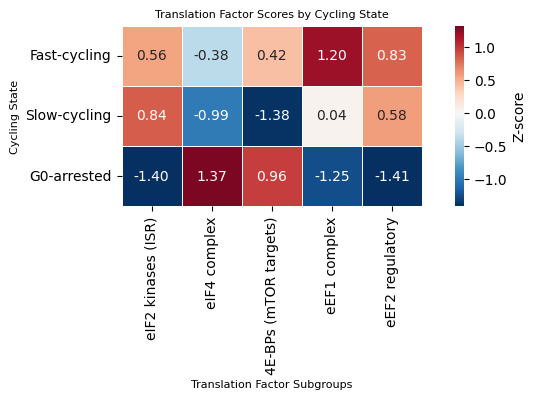

In [ ]:
# Heatmap of translation factor subgroup scores by cycling state
from scipy.stats import zscore

# Define score columns
score_cols = [
    'eIF2_kinases_ISR',
    'eIF4_complex',
    '4E-BPs_mTOR_targets',
    'eEF1_complex',
    'eEF2_regulatory'
]

# Extract scores and group by cycling state
scores_df = adata.obs[score_cols + ['cycling_state_oren']].copy()

# Calculate mean scores per cycling state
mean_scores = scores_df.groupby('cycling_state_oren')[score_cols].mean()

# Reorder rows
order = ["Fast-cycling", "Slow-cycling", "G0-arrested"]
mean_scores = mean_scores.loc[order]

# Scale (z-score) across cycling states for each gene set
scaled_scores = mean_scores.apply(zscore, axis=0)

# Rename columns for cleaner display
column_labels = {
    'eIF2_kinases_ISR': 'eIF2 kinases (ISR)',
    'eIF4_complex': 'eIF4 complex',
    '4E-BPs_mTOR_targets': '4E-BPs (mTOR targets)',
    'eEF1_complex': 'eEF1 complex',
    'eEF2_regulatory': 'eEF2 regulatory'
}
scaled_scores.columns = [column_labels[c] for c in scaled_scores.columns]

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    scaled_scores,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Z-score'},
    ax=ax,
    robust=True,
    square=True
)
ax.set_xlabel('Translation Factor Subgroups', fontsize=8)
ax.set_ylabel('Cycling State', fontsize=8)
ax.set_title('Translation Factor Scores by Cycling State', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(figure_dir + "translation_subgroups_heatmap.pdf", bbox_inches="tight")
plt.show()

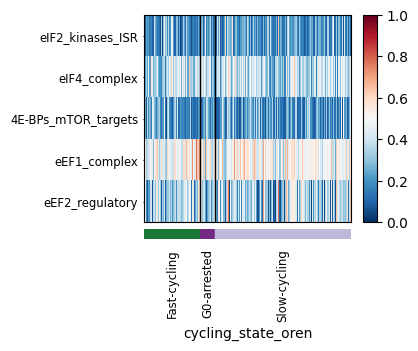

In [27]:
sc.pl.heatmap(
    adata,
    var_names=score_cols,
    groupby="cycling_state_oren",
    cmap="RdBu_r",
    show_gene_labels=True,
    standard_scale="var",
    figsize=(3, 3),
    swap_axes=True,
    save="translation_subgroups_heatmap.pdf",
)

eIF genes: 54/54 present
eEF genes: 14/14 present


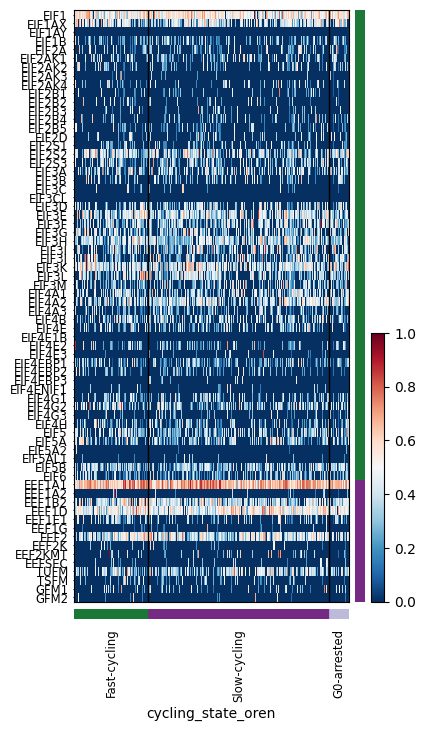

In [50]:
# Filter to genes present in adata
eIF_present = [g for g in eIF_genes if g in adata.var_names]
eEF_present = [g for g in eEF_genes if g in adata.var_names]
all_genes = eIF_present + eEF_present

print(f"eIF genes: {len(eIF_present)}/{len(eIF_genes)} present")
print(f"eEF genes: {len(eEF_present)}/{len(eEF_genes)} present")

# Build gene-group dict for the sidebar annotation
var_group_labels = ["eIF"] * len(eIF_present) + ["eEF"] * len(eEF_present)

# Reorder cells so cycling states are grouped together
order = ["Fast-cycling", "Slow-cycling", "G0-arrested"]
adata.obs["cycling_state_oren"] = pd.Categorical(
    adata.obs["cycling_state_oren"], categories=order, ordered=True
)

sc.pl.heatmap(
    adata,
    var_names=all_genes,
    groupby="cycling_state_oren",
    var_group_positions=[
        (0, len(eIF_present) - 1),
        (len(eIF_present), len(all_genes) - 1),
    ],
    var_group_labels=["eIF", "eEF"],
    var_group_rotation=0,
    standard_scale="var",
    cmap="RdBu_r",
    swap_axes=True,
    dendrogram=False,
    figsize=(4, 8),
    show_gene_labels=True,
    save="_eIF_eEF_per_gene_by_cycling_state.pdf",
)


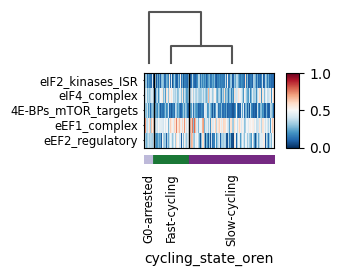

In [42]:
# Reorder cells so cycling states are grouped together
order = ["Fast-cycling", "Slow-cycling", "G0-arrested"]
adata.obs["cycling_state_oren"] = pd.Categorical(
    adata.obs["cycling_state_oren"], categories=order, ordered=True
)

sc.pl.heatmap(
    adata,
    var_names=score_cols,
    groupby="cycling_state_oren",
    var_group_rotation=0,
    standard_scale="var",
    cmap="RdBu_r",
    swap_axes=True,
    dendrogram=True,
    figsize=(2, 2),
    show_gene_labels=True,
    save="_eIF_eEF_per_cell_by_cycling_state.pdf",
)


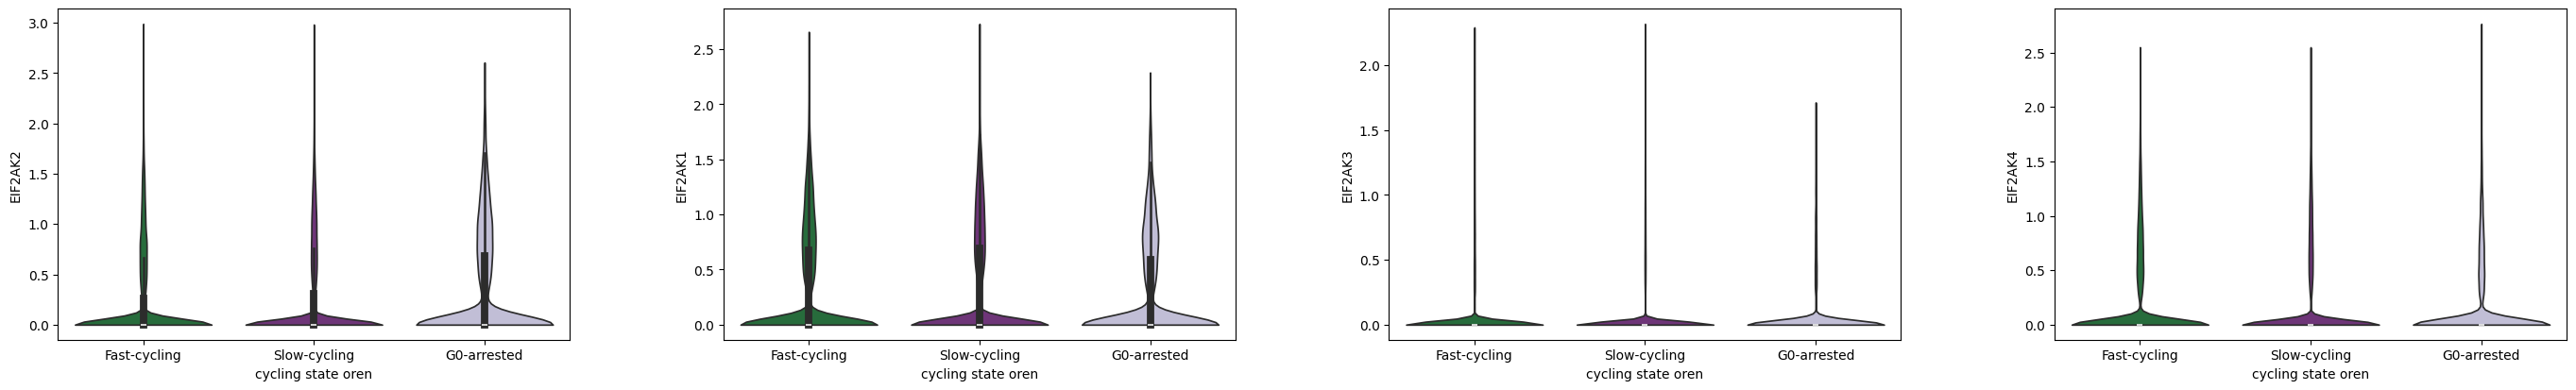

In [49]:
isr_genes = ["EIF2AK2", "EIF2AK1", "EIF2AK3", "EIF2AK4"]

sc.pl.violin(
    adata,
    keys=isr_genes,
    groupby="cycling_state_oren",
    order=["Fast-cycling", "Slow-cycling", "G0-arrested"],
    inner="box",
    size=0,
    save="_isr_genes_by_cycling_state.pdf",
)